In [11]:
# Carregar os dados a partir do arquivo vendas.csv.
import pandas as pd
import sqlite3
from google.colab import files

arquivo_vendas = '/content/vendas.csv'

df_vendas = pd.read_csv(arquivo_vendas)

In [12]:
# Exibir informações básicas:
# Mostrar as 5 primeiras linhas do dataset.
df_vendas.head()

,data,produto,categoria,quantidade,preco_unitario,cliente,regiao
0,2025-12-09,Headset G,Periféricos,1,2759,Fernanda,Sudeste
1,2025-03-12,Armário P,Móveis,2,4516,Rafael,Norte
2,2025-11-24,Mesa Escritório N,Móveis,1,4347,Rafael,Sudeste
3,2025-09-14,Tênis T,Vestuário,3,3046,Ana,Norte
4,2025-08-03,Boné V,Vestuário,2,4453,Bruno,Centro-Oeste


In [14]:
# Exibir o número total de registros (linhas).
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   data            100 non-null    object
 1   produto         100 non-null    object
 2   categoria       100 non-null    object
 3   quantidade      100 non-null    int64 
 4   preco_unitario  100 non-null    int64 
 5   cliente         100 non-null    object
 6   regiao          100 non-null    object
dtypes: int64(2), object(5)
memory usage: 5.6+ KB


In [15]:
# Calcular a receita total (coluna quantidade multiplicada pela coluna preco_unitario).
df_vendas['receita_total'] = df_vendas['quantidade'] * df_vendas['preco_unitario']
df_vendas.head()

,data,produto,categoria,quantidade,preco_unitario,cliente,regiao,receita_total
0,2025-12-09,Headset G,Periféricos,1,2759,Fernanda,Sudeste,2759
1,2025-03-12,Armário P,Móveis,2,4516,Rafael,Norte,9032
2,2025-11-24,Mesa Escritório N,Móveis,1,4347,Rafael,Sudeste,4347
3,2025-09-14,Tênis T,Vestuário,3,3046,Ana,Norte,9138
4,2025-08-03,Boné V,Vestuário,2,4453,Bruno,Centro-Oeste,8906


In [18]:
# Fazer consultas específicas:
# Filtrar e exibir as vendas da categoria "Eletrônicos".
conexao = sqlite3.connect(':memory:')

df_vendas.to_sql(
    'vendas',
    conexao,
    index=False,
    if_exists='replace'
)

resultado = pd.read_sql_query(
    "SELECT * FROM vendas WHERE categoria = 'Eletrônicos' ",
    conexao
)
display(resultado)

,data,produto,categoria,quantidade,preco_unitario,cliente,regiao,receita_total
0,2025-07-24,Tablet D,Eletrônicos,2,4893,Fernanda,Sudeste,9786
1,2025-05-20,Monitor B,Eletrônicos,1,3060,Lucas,Sul,3060
2,2025-06-01,Celular A,Eletrônicos,3,516,João,Centro-Oeste,1548
3,2025-04-22,Celular A,Eletrônicos,2,1018,Fernanda,Nordeste,2036
4,2025-11-24,Notebook X,Eletrônicos,1,2670,Ana,Sul,2670
5,2025-05-30,Tablet D,Eletrônicos,4,2575,Maria,Nordeste,10300
6,2025-09-19,Notebook X,Eletrônicos,2,2778,Rafael,Norte,5556
7,2025-01-30,Notebook X,Eletrônicos,5,1006,Lucas,Sudeste,5030
8,2025-07-07,Tablet D,Eletrônicos,2,2533,Camila,Sul,5066
9,2025-11-20,Notebook X,Eletrônicos,4,3998,Pedro,Nordeste,15992


In [19]:
# Identificar e exibir o produto mais vendido (em quantidade).
resultado = pd.read_sql_query(
    "SELECT produto, SUM(quantidade) as quantidade FROM vendas GROUP BY produto ORDER BY quantidade DESC LIMIT 1",
    conexao
)
display(resultado)

,produto,quantidade
0,Sofá Q,30


In [21]:
# Descobrir e exibir a região com maior valor de compras.
resultado = pd.read_sql_query(
    "SELECT regiao, SUM(receita_total) as valor_total_compra FROM vendas GROUP BY regiao ORDER BY receita_total DESC LIMIT 1",
    conexao
)
display(resultado)

,regiao,valor_total_compra
0,Norte,149076


     categoria  receita_total
0  Eletrônicos         239389
1       Móveis         228789
2  Periféricos         162285
3    Vestuário         215389


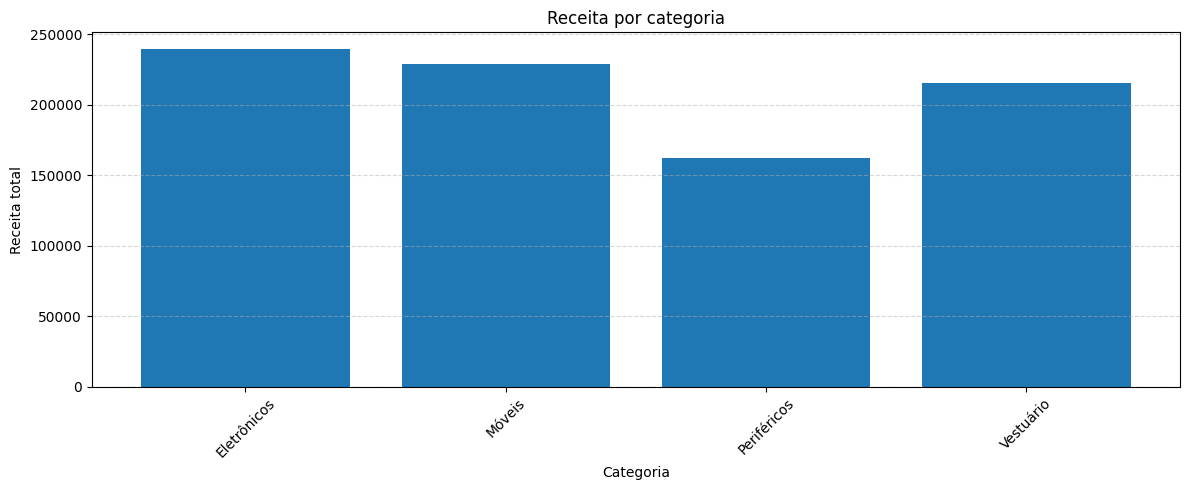

In [31]:
# Desafio extra (opcional)
# Gerar visualizações:
# Gráfico de barras mostrando a receita por categoria.
receita_por_categoria = df_vendas.groupby('categoria')['receita_total'].sum().reset_index()
print(receita_por_categoria)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.bar(
    receita_por_categoria['categoria'].astype(str),
    receita_por_categoria['receita_total'],
    )

plt.title('Receita por categoria')
plt.xlabel('Categoria')
plt.ylabel('Receita total')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            100 non-null    datetime64[ns]
 1   produto         100 non-null    object        
 2   categoria       100 non-null    object        
 3   quantidade      100 non-null    int64         
 4   preco_unitario  100 non-null    int64         
 5   cliente         100 non-null    object        
 6   regiao          100 non-null    object        
 7   receita_total   100 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 6.4+ KB
    mes  receita_total
0     1          67096
1     2          59928
2     3         103280
3     4          63062
4     5          56811
5     6          77002
6     7          70486
7     8         116042
8     9          45221
9    10          44500
10   11          70494
11   12          71930


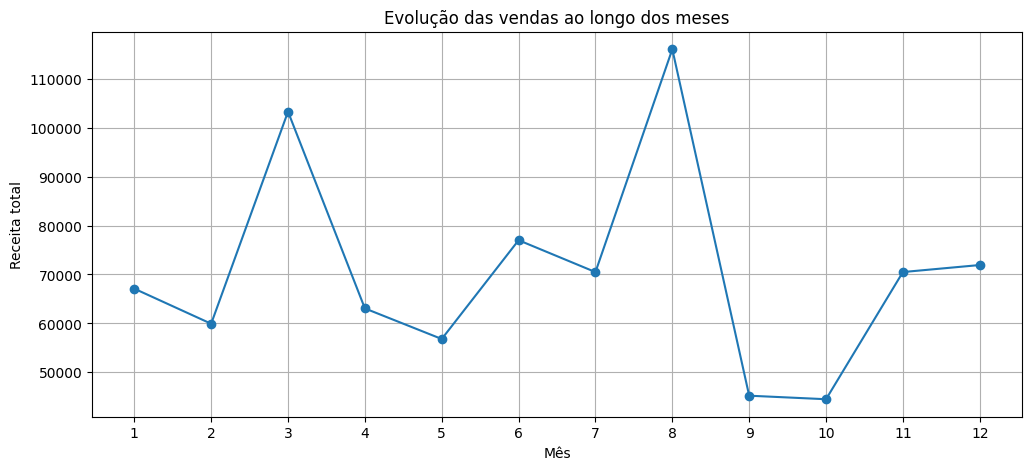

Maior receita: 8 - R$ 116042.00
Menor receita: 10 - R$ 44500.00


In [23]:
# Gráfico de linha mostrando a evolução das vendas por mês.
df_vendas['data'] = pd.to_datetime(df_vendas['data'])
df_vendas.info()

df_vendas['mes'] = df_vendas['data'].dt.month
df_vendas.head()

receita_por_mes = df_vendas.groupby('mes')['receita_total'].sum().reset_index()
print(receita_por_mes)

plt.figure(figsize=(12, 5))

plt.plot(
    receita_por_mes['mes'].astype(str),
    receita_por_mes['receita_total'],
    marker='o'
    )

plt.title('Evolução das vendas ao longo dos meses')
plt.xlabel('Mês')
plt.ylabel('Receita total')
plt.grid()
plt.show()

In [32]:
# Extra (opcional):
# Criar um relatório exportado em .xlsx ou .pdf.
receita_por_categoria.to_excel(
    '/content/receita_por_categoria.xlsx',
    index=False
)

files.download('/content/receita_por_categoria.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# Montar uma tabela dinâmica com receita por região × categoria.
tabela_dinamica = pd.pivot_table(
    df_vendas,
    values='receita_total',
    index='regiao',
    columns='categoria',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='Total Geral'
)

display(tabela_dinamica)

categoria,Eletrônicos,Móveis,Periféricos,Vestuário,Total Geral
regiao,,,,,
Centro-Oeste,39546,44884,25192,24106,133728
Nordeste,51890,22870,24383,52659,151802
Norte,38116,67464,11935,31561,149076
Sudeste,51158,62888,69055,62504,245605
Sul,58679,30683,31720,44559,165641
Total Geral,239389,228789,162285,215389,845852
